
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E02_sklearn.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

## 0. EDA (*)

In the whole exercise, we will work with the "mpg" dataset from seaborn dataset. Start by loading dataset "mpg" from the ```load_dataset``` method in seaborn module. The goal will be to use linear regression to predict mpg - miles per gallon.

&nbsp; a) Start by doing some initial EDA such as info(), describe() and figure out what you want to do with the missing values.

&nbsp; b) Use describe only on those columns that are relevant to get statistical information from.

&nbsp; c) Make some plots on some of the columns that you find interesting.

&nbsp; d) Check if there are any columns you might want to drop.

<details>

<summary>Answer</summary>

a) I have chosen to drop the rows, but it doesn't neccessary have to be the best method. Maybe some NaNs should be filled somehow?

b)
|      |      mpg |   cylinders |   displacement |   horsepower |   weight |   acceleration |
|:-----|---------:|------------:|---------------:|-------------:|---------:|---------------:|
| mean | 23.4459  |     5.47194 |        194.412 |     104.469  | 2977.58  |       15.5413  |
| std  |  7.80501 |     1.70578 |        104.644 |      38.4912 |  849.403 |        2.75886 |
| min  |  9       |     3       |         68     |      46      | 1613     |        8       |
| 25%  | 17       |     4       |        105     |      75      | 2225.25  |       13.775   |
| 50%  | 22.75    |     4       |        151     |      93.5    | 2803.5   |       15.5     |
| 75%  | 29       |     8       |        275.75  |     126      | 3614.75  |       17.025   |
| max  | 46.6     |     8       |        455     |     230      | 5140     |       24.8     |


c) Here are some example plots

<img src="../data/EDA_mpg.png" height="400"/>

d) I have chosen to drop the columns origin and name. Think yourself if it is reasonable and feel free to experiment. Also there might be some domain experts in our class, that you can ask.

</details>

---

In [1]:
#a)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.constants import degree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

mpg_data = sns.load_dataset("mpg")

mpg_data.describe()
mpg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [2]:
mpg_data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [3]:
mpg_data = mpg_data.dropna()

In [4]:
mpg_data["horsepower"] = mpg_data["horsepower"].fillna(mpg_data["horsepower"].median())

In [5]:
#b)

cols = ["mpg", "cylinders", "displacement",
        "horsepower", "weight", "acceleration"]

mpg_data[cols].describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000


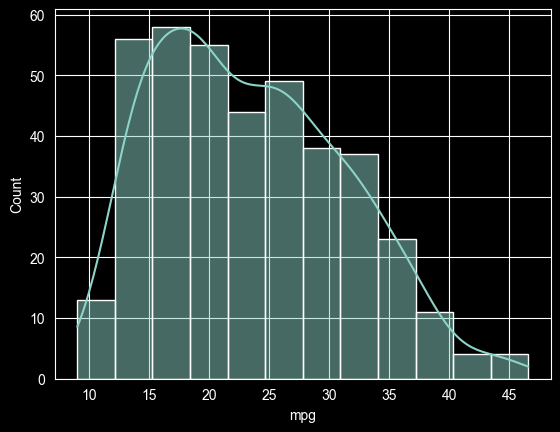

In [6]:
#c)

sns.histplot(mpg_data["mpg"], kde=True)
plt.show()

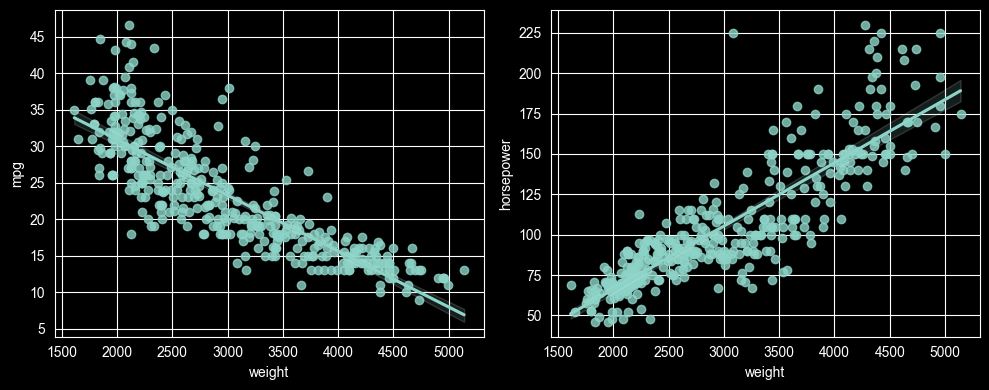

In [7]:
#sns.scatterplot(x="weight", y="mpg", data=mpg_data)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.regplot(x="weight", y="mpg", data=mpg_data, ax=axes[0]) #regression

sns.regplot(x="weight", y="horsepower", data=mpg_data, ax=axes[1]) #regression

plt.tight_layout()
plt.show()


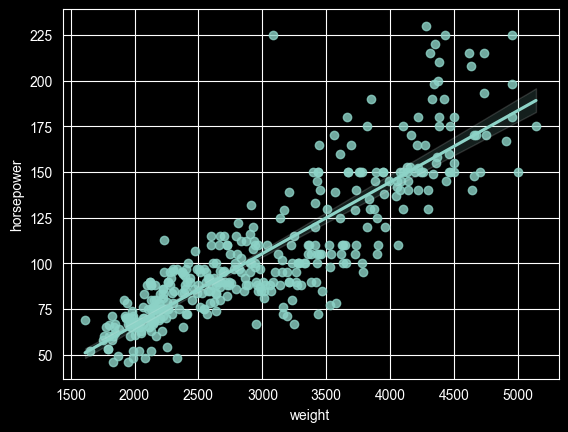

In [8]:
sns.regplot(x="weight", y="horsepower", data=mpg_data) #regression
plt.show()

## 1. Train|test split (*)

We want to predict the "mpg", split up X and y, and perform train|test split using scikit-learn. Choose test_size of 0.2 and random_state 42. Control the shapes of each X_train, X_test, y_train, y_test.  

<details>

<summary>Answer</summary>

Do a manual calculation to check against the shapes after train|test split. 

</details>

---

In [9]:
from sklearn.model_selection import train_test_split

X = mpg_data[["displacement", "horsepower", "weight", "acceleration"]]
y = mpg_data["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (313, 4)
X_test : (79, 4)
y_train: (313,)
y_test : (79,)


## 2. Function for evaluation (*)

Create a function for training a regression model, predicting and computing the metrics MAE, MSE, RMSE. It should take in parameters of X_train, X_test, y_train, y_test, model. Now create a linear regression model using scikit-learns ```LinearRegression()``` (OLS normal equation with SVD) and call your function to get metrics.

<details>

<summary>Answer</summary>

MAE 2.50

MSE 10.50

RMSE 3.24

</details>

In [10]:
from __future__ import annotations

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

def evaluate_regression_model(X_train, X_test, y_train, y_test, model):
    if X_train.isna().any().any() or X_test.isna().any().any():
        raise ValueError()
    if y_train.isna().any() or y_test.isna().any():
        raise ValueError()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = float(np.sqrt(mse))

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "y_pred": y_pred,
        "model": model,
    }


lin_reg = LinearRegression()
results = evaluate_regression_model(X_train, X_test, y_train, y_test, lin_reg)

print(f"MAE  {results['mae']:.2f}")
print(f"MSE  {results['mse']:.2f}")
print(f"RMSE {results['rmse']:.2f}")


MAE  3.51
MSE  18.07
RMSE 4.25


---
## 3. Compare models (*)

Create the following models 
- Linear regression (SVD)
- Linear regression (SVD) with scaled data (feature standardization)
- Polynomial linear regression with degree 1
- Polynomial linear regression with degree 2
- Polynomial linear regression with degree 3

Make a DataFrame with evaluation metrics and model. Which model performed overall best?

<details>

<summary>Answer</summary>

|      |   Linear regr. SVD |   Linear regr. SVD scaled |   Linear regr. SGD |   Polynom. regr. deg 1 |   Polynom. regr. deg 2 |   Polynom. regr. deg 3 |
|:-----|-------------------:|--------------------------:|-------------------:|-----------------------:|-----------------------:|-----------------------:|
| mae  |            2.50386 |                   2.50386 |            2.53515 |                2.50386 |                1.98048 |                2.11788 |
| mse  |           10.5024  |                  10.5024  |           10.8908  |               10.5024  |                7.41986 |                9.27353 |
| rmse |            3.24074 |                   3.24074 |            3.30012 |                3.24074 |                2.72394 |                3.04525 |

</details>

---

In [11]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

models = {
    "Linear regression (SVD)": LinearRegression(),

    "Linear regression (SVD) scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression()),
    ]),

    "Polynomial regression degree 1": Pipeline([
        ("poly", PolynomialFeatures(degree=1, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression()),
    ]),

    "Polynomial regression degree 2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression()),
    ]),

    "Polynomial regression degree 3": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression()),
    ]),
}

In [12]:
rows = []

for name, model in models.items():
    res = evaluate_regression_model(X_train, X_test, y_train, y_test, model)
    rows.append({
        "model": name,
        "mae": res["mae"],
        "mse": res["mse"],
        "rmse": res["rmse"],
    })

comparison_df = (
    pd.DataFrame(rows)
      .set_index("model")
      .sort_values("rmse")
)

comparison_df

,mae,mse,rmse
model,,,
Polynomial regression degree 2,3.090316,16.384322,4.047755
Linear regression (SVD),3.509584,18.065922,4.250403
Linear regression (SVD) scaled,3.509584,18.065922,4.250403
Polynomial regression degree 1,3.509584,18.065922,4.250403
Polynomial regression degree 3,3.193625,20.646841,4.543880


In [14]:
best_model_name = comparison_df.index[0]
best_rmse = comparison_df.iloc[0]["rmse"]

print(f"Best model: {best_model_name}")
print(f"Best RMSE : {best_rmse:.3f}")

Best model: Polynomial regression degree 2
Best RMSE : 4.048


Kopplat till uppgift 3.

Skalning påverkar oftast inte resultatet så mycket för vanlig linjär regression, men det är ändå bra att göra – och viktigt för vissa andra modeller.

Polynomgrad 2 kan ge bättre resultat om sambandet inte är helt linjärt.

Polynomgrad 3 kan ibland bli ännu bättre, men risken är att modellen anpassar sig för mycket till träningsdatan. Därför är det bra att jämföra RMSE på testdatan.


## 4. Further explorations (**)

Feel free to further explore the dataset, for example you could choose to 
- drop different columns
- find out feature importance in polynomial models
- fine tune further for a specific model by exploring hyperparameters (check documentation which type of parameters that can be changed)

---

Kokchun Giang, Raphael Korsoski

---